In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading breast cancer dataset
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns= data.feature_names)
df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Checking for NaN values
df.isna().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [4]:
# Checking for dtypes
df.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

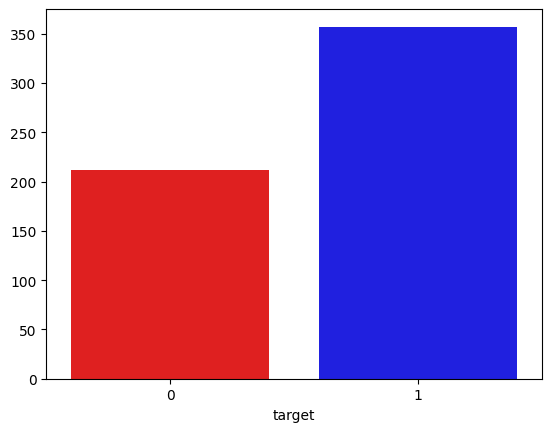

In [5]:
# Target distribution
counts = df['target'].value_counts()

sns.barplot(x= counts.index, y= counts.values, palette= ['red', 'blue'])
plt.show()

In [16]:
# Splitting data
train_size = int(0.8 * len(df))

X_train = df.iloc[:train_size, :-1]
y_train = df.iloc[:train_size, -1]

X_test = df.iloc[train_size:, :-1].reset_index(drop= True)
y_test = df.iloc[train_size:, -1].reset_index(drop= True)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (455, 30)
X_test shape: (114, 30)


In [18]:
# Normalizing data
X_std = X_train.mean()
X_mean = X_train.std()

X_train_scaled = (X_train - X_mean) / X_std

In [19]:
# Training
from algorithm import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

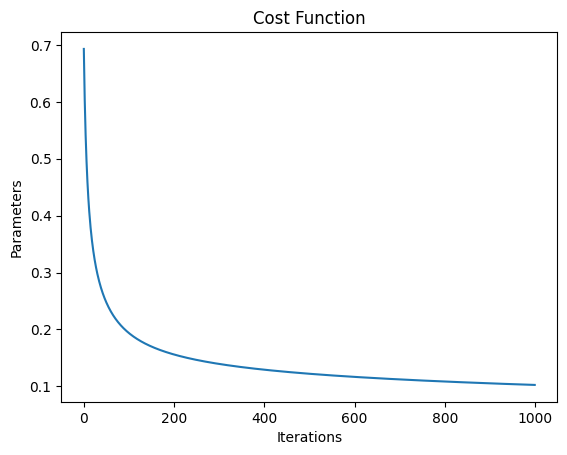

In [20]:
# Plotting the cost function
plt.plot(model.j_history_)
plt.title("Cost Function")
plt.ylabel("Parameters")
plt.xlabel("Iterations")
plt.show()

In [23]:
# Model parameters
print(f"Weights: {model.coef_}")
print(f"Bias: {model.intercept_}")
print(f"Stopping iteration: {model.iter_}")

Weights: [ 0.09434811 -0.49662719  0.06065976 -0.73392873  0.51901649  0.01240204
 -1.16235477 -1.39584894  0.60159377  0.84009811 -0.77220475  0.01618258
 -0.55434608 -1.72915934 -0.08427534  0.50761851  0.52121256  0.19415073
  0.44735286  0.75841969 -0.23503336 -0.75958558 -0.23989764 -1.32672464
  0.07705981 -0.75476785 -1.21662386 -1.20394699 -0.00835455  0.31296572]
Bias: 0.8578279415433636
Stopping iteration: 1000


In [24]:
# Predictions
X_test_scaled = (X_test - X_mean) / X_std
y_pred = model.predict(X_test_scaled)

In [25]:
# Evaluation metrics
from algorithm import Metrics

metrics = Metrics()

accuracy = metrics.accuracy(y_test, y_pred)
precision = metrics.precison(y_test, y_pred)
recall = metrics.recall(y_test, y_pred)
f1_score = metrics.f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_score}")

Accuracy: 0.9649122807017544
Precision: 0.9883720930232558
Recall: 0.9659090909090909
F1 Score: 0.9770114942528736


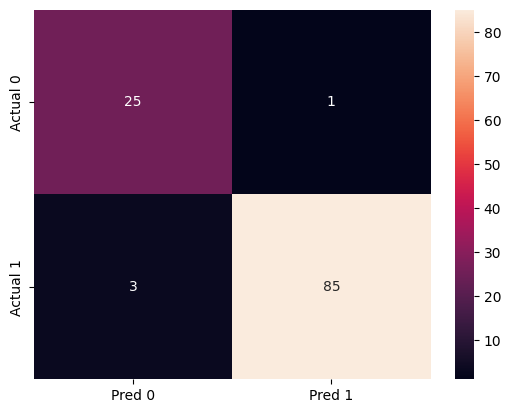

In [26]:
# Confusion Matrix
cm = metrics.compute_confusion_matrix(y_test, y_pred)

sns.heatmap(cm['matrix'], annot= True, xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.show()